### Audio-apparaten controleren
  
Draai de onderstaande code om te zien welke audio-apparaten je computer herkent.  

**Wat moet je weten?**  
- **Standaardinstelling:** In de opnamecode staat `device=0` ingesteld. Bij de meeste computers is dit de juiste microfoon.
- **Wanneer aanpassen?** Krijg je een foutmelding of hoor je niets? Kijk dan in de lijst hieronder:
	- Zoek naar de regel met het pijltje **`>`**. Dit is het standaardapparaat van je systeem.
	- Het getal aan de linkerkant van die regel is het **Device ID**.
	- Pas in de opname-code de waarde bij `device=` aan naar dit getal.
- **Kanalen:** Een microfoon herken je aan `(minimaal 1 in, 0 out)`.

**⚠️ Let op: Lijst verversen**  
Als je een USB-microfoon inplugt of eruit haalt, verandert de lijst niet direct. Python "onthoudt" de oude lijst.  
   1. Sla je werk op.
   2. Klik bovenin op **Kernel** -> **Restart**.
   3. Draai de Audio-apparaten controleren opnieuw. Pas dan zie je de actuele lijst.

In [1]:
# Audio-apparaten controleren

import sounddevice as sd

# Toon de lijst met alle beschikbare audio-apparaten
print("Lijst met gedetecteerde apparaten:")
print(sd.query_devices())

Lijst met gedetecteerde apparaten:
   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Microphone (USB Audio Device ), MME (2 in, 0 out)
   2 Microphone Array (Realtek(R) Au, MME (2 in, 0 out)
   3 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  4 Speakers (USB Audio Device ), MME (0 in, 2 out)
   5 Speakers (Realtek(R) Audio), MME (0 in, 2 out)
   6 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
   7 Microphone (USB Audio Device ), Windows DirectSound (2 in, 0 out)
   8 Microphone Array (Realtek(R) Audio), Windows DirectSound (2 in, 0 out)
   9 Primary Sound Driver, Windows DirectSound (0 in, 2 out)
  10 Speakers (USB Audio Device ), Windows DirectSound (0 in, 2 out)
  11 Speakers (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
  12 Speakers (Realtek(R) Audio), Windows WASAPI (0 in, 2 out)
  13 Speakers (USB Audio Device ), Windows WASAPI (0 in, 2 out)
  14 Microphone Array (Realtek(R) Audio), Windows WASAPI (2 in, 0 out)
  15 Microphone (USB Audio

⚠️ test.wav bestaat al. [Enter] = overschrijven, [q] = stop:  


🎤 Start opname...
🛑 Opname gestopt.
💾 Opname succesvol opgeslagen als test.wav
⚠️ Waarschuwing: Clipping gedetecteerd! Geluid is mogelijk vervormd.


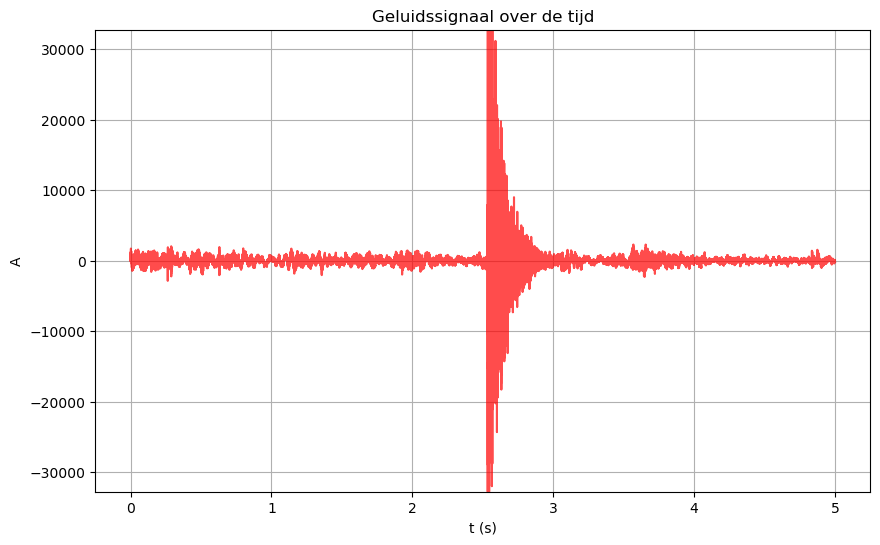

In [276]:
# Cel 1
import sounddevice as sd
import soundfile as sf
import os
import numpy as np

# Audioconfiguratie
Rate = 44100       # Samplefrequentie (CD-kwaliteit, legt vast tot ~22kHz)
duration = 5    # Opnameduur in seconden
Channels = 1       # Aantal kanalen (1=mono, 2=stereo)
output_file = "test.wav"  # Naam van het doelbestand

# Controle op bestaand bestand
doorgaan = True
if os.path.exists(output_file):
    keuze = input(f"⚠️ {output_file} bestaat al. [Enter] = overschrijven, [q] = stop: ").lower()
    if keuze == 'q':
        print("🛑 Opname afgebroken.")
        doorgaan = False

if doorgaan:
    print("🎤 Start opname...")
    recording = sd.rec(
        int(duration * Rate), 
        samplerate = Rate, 
        channels = Channels, 
        dtype = 'float32',
        device = None     # Pakt automatisch het apparaat met het > pijltje
    )
    sd.wait()
    print("🛑 Opname gestopt.")

    # Opslaan
    sf.write(output_file, recording, Rate)
    print(f"💾 Opname succesvol opgeslagen als {output_file}")

    plot_color = 'green'
    # Clipping-detectie (kijkt naar absolute pieken boven 0.99)
    if np.any(np.abs(recording) >= 0.99):
        print("⚠️ Waarschuwing: Clipping gedetecteerd! Geluid is mogelijk vervormd.")
        plot_color = 'red'
    else:
        print("✅ Geen clipping gedetecteerd.")

# extra visuele controle
import matplotlib.pyplot as plt

time = np.linspace(0., duration, len(recording))


recording_scale = recording * 32768  # omzetten naar een 16-bit audio scale
# Grafiek plotten
plt.figure(figsize=(10, 6))
plt.plot(time, recording_scale, color=plot_color, alpha=0.7)

# Instellen van de assen voor 16-bit audio
plt.ylim(-32768, 32768)

plt.title('Geluidssignaal over de tijd')
plt.xlabel('t (s)')
plt.ylabel('A')
plt.grid(True)
plt.show()


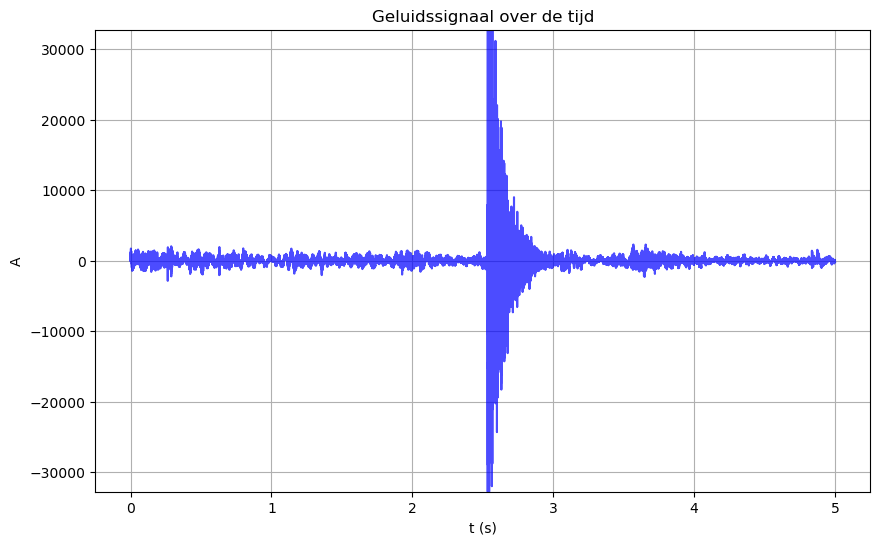

In [277]:
# Cel 2
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import pandas as pd

# Inlezen van het .wav bestand
file_path = 'test.wav'
sampling_rate, audio_data = wavfile.read(file_path)

# Tijd-array maken
duration = len(audio_data) / sampling_rate
time = np.linspace(0., duration, len(recording))

# Grafiek plotten
plt.figure(figsize=(10, 6))
plt.plot(time, audio_data, color='blue', alpha=0.7)

# Instellen van de assen voor 16-bit audio
plt.ylim(-32768, 32768)

plt.title('Geluidssignaal over de tijd')
plt.xlabel('t (s)')
plt.ylabel('A')
plt.grid(True)
plt.show()



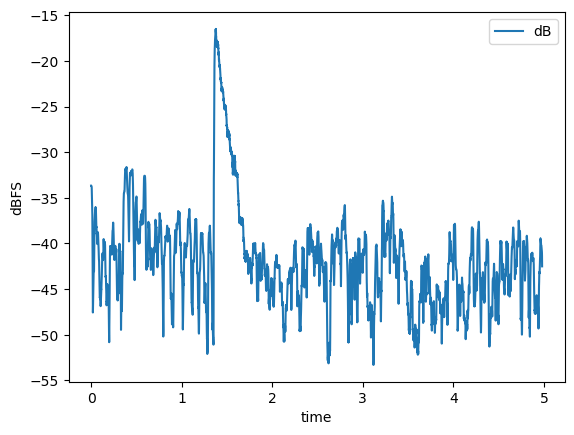

In [215]:
import pandas as pd
pd.set_option('display.max_rows', None)

df = pd.DataFrame(audio_data)
window_size = int(0.02*sampling_rate)
data = rolling_mean = np.convolve(audio_data, np.ones(window_size)/window_size, mode='valid')

audio = audio_data.astype(np.float32) / 32768.0
squared = audio**2
rolling = np.convolve(squared, np.ones(window_size)/window_size, mode='valid')
rms = np.sqrt(rolling)

df = pd.DataFrame(rms, columns=["rms"])

# Remove NaNs safely
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Convert to dBFS
df["dB"] = 20 * np.log10(df["rms"] + 1e-12)
df["time"] = np.arange(len(df)) / sampling_rate

df.plot(x = "time", y = "dB")
plt.ylabel("dBFS")
plt.show()



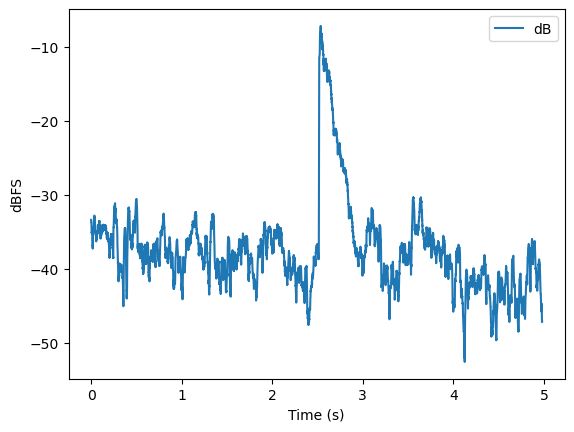

Nagalmtijd (RT60): 1.27 s


In [278]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)

window_size = int(0.02 * sampling_rate)

audio = audio_data.astype(np.float32) / 32768.0
squared = audio**2
rolling = np.convolve(squared, np.ones(window_size)/window_size, mode='valid')
rms = np.sqrt(rolling)

df = pd.DataFrame(rms, columns=["rms"])

df = df.replace([np.inf, -np.inf], np.nan).dropna()

df["dB"] = 20 * np.log10(df["rms"] + 1e-12)
df["time"] = np.arange(len(df)) / sampling_rate

# Plot
df.plot(x="time", y="dB")
plt.ylabel("dBFS")
plt.xlabel("Time (s)")
plt.show()

# --- NAGALMTIJD ---
Lmax = df["dB"].max()
idx_max = df["dB"].idxmax()

after_peak = df.loc[idx_max:]

L1 = Lmax - 5
L2 = Lmax - 35

t1 = after_peak.loc[after_peak["dB"] <= L1, "time"].iloc[0]
t2 = after_peak.loc[after_peak["dB"] <= L2, "time"].iloc[0]

RT30 = t2 - t1
RT60 = 2 * RT30

print(f"Nagalmtijd (RT60): {RT60:.2f} s")


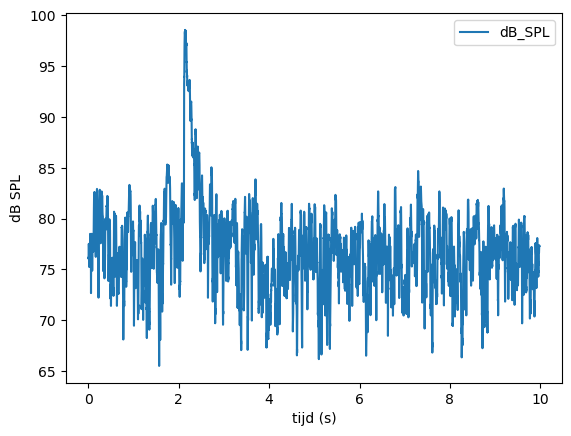

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)

df = pd.DataFrame(audio_data)

window_size = int(0.02 * sampling_rate)

audio = audio_data.astype(np.float32) / 32768.0
squared = audio**2

rolling = np.convolve(squared, np.ones(window_size)/window_size, mode='valid')
rms = np.sqrt(rolling)

df = pd.DataFrame(rms, columns=["rms"])

df = df.replace([np.inf, -np.inf], np.nan).dropna()

# dBFS
df["dB"] = 20 * np.log10(df["rms"] + 1e-12)

# tijd
df["time"] = np.arange(len(df)) / sampling_rate

# kalibratie
offset = 120   # bepaal deze met referentiemeting
df["dB_SPL"] = df["dB"] + offset

# plot
df.plot(x="time", y="dB_SPL")
plt.ylabel("dB SPL")
plt.xlabel("tijd (s)")
plt.show()